# L=1 z(t) Autocorrelation Analysis

Compute C(Δτ) = < z(τ) · z(τ + Δτ) > for single-qubit trajectories.
This notebook loads `raw_trajectories_L1_g*.npz` from the active worktree and computes the absolute autocorrelation for all lags.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from quantum_measurement.utilities.autocorr import autocorr_ensemble


# data = np.load(DATA_PATH, allow_pickle=True)
# print('Keys:', data.files)
# z_trajs = data['z_trajectories']
# if z_trajs.ndim == 3 and z_trajs.shape[2] == 1:
#     z_trajs = z_trajs[:, :, 0]
# print('Loaded z_trajs shape:', z_trajs.shape)

# QUICK_RUN = True
# MAX_TRIALS_QUICK = 100
# if QUICK_RUN:
#     z_trajs = z_trajs[:min(MAX_TRIALS_QUICK, z_trajs.shape[0])]
#     print('Using subset for quick run; new shape:', z_trajs.shape)

In [3]:
# Single-trajectory simulation (optional)
from quantum_measurement.sse_simulation.sse import SSEWavefunctionSimulator

RUN_SINGLE_SIM = True
SINGLE_GAMMA = 0.01
SINGLE_J = 1.0
SINGLE_N_STEPS = 1000000
SINGLE_DT = 0.001

def epsilon_from_g(g: float, dt: float, J: float) -> float:
    return (g*dt)**0.5

if RUN_SINGLE_SIM:
    epsilon = epsilon_from_g(SINGLE_GAMMA, SINGLE_DT, SINGLE_J)
    sim = SSEWavefunctionSimulator(
        epsilon=epsilon,
        N_steps=SINGLE_N_STEPS,
        J=SINGLE_J,
        initial_state="bloch_equator",
    )
    Q_single, z_single, xi_single = sim.simulate_trajectory()
    print(f"Single trajectory done: Q={Q_single:.4f}, len(z)={len(z_single)}")

Single trajectory done: Q=14.6495, len(z)=1000001


In [ ]:
from quantum_measurement.utilities.autocorr import autocorr_single

# Select a single trajectory: simulated if available, otherwise use the first loaded trajectory.
if 'z_single' in globals():
    z_source = z_single
elif 'z_trajs' in globals() and len(z_trajs) > 0:
    z_source = z_trajs[0]
else:
    raise ValueError('No single trajectory available. Run the single-trajectory simulation or load data first.')

C_single = autocorr_single(z_source)
lag_single = np.arange(C_single.size)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(z_source, color='tab:blue')
axes[0].set_title('Single trajectory z(t)')
axes[0].set_xlabel('step')
axes[0].set_ylabel('z(t)')
axes[0].grid(True)

axes[1].plot(lag_single, C_single, marker='.', markersize=4, color='tab:orange')
axes[1].set_title('Autocorr of single trajectory')
axes[1].set_xlabel('Δτ (lag)')
axes[1].set_ylabel('<z(t) z(t+Δτ)>')
axes[1].grid(True)

plt.tight_layout()
plt.show()

ValueError: No single trajectory available. Run the single-trajectory simulation or load data first.

In [ ]:
# Cxi_z analysis for a single trajectory
if 'xi_single' not in globals() or 'z_single' not in globals():
    raise ValueError('Need xi_single and z_single from the single-trajectory simulation.')

max_l = min(10000, len(z_single) - 1)

# Match the reference definition: Czz(l) = <z_i z_{i+l}>, Cxi_z(l) = <(xi_i/epsilon) z_{i+l}>
epsilon_used = epsilon_from_g(SINGLE_GAMMA, SINGLE_DT, SINGLE_J)

Czz = np.zeros(max_l + 1)
Cxi_z = np.zeros(max_l + 1)

Czz[0] = np.mean(z_single ** 2)
Cxi_z[0] = np.mean((xi_single / epsilon_used) * z_single)

for l in range(1, max_l + 1):
    Czz[l] = np.mean(z_single[: -l] * z_single[l:])
    Cxi_z[l] = np.mean((xi_single[: -l] / epsilon_used) * z_single[l:])

plt.figure(figsize=(8, 5))
plt.plot(range(max_l + 1), Czz, label=r"$C_{zz}(l)$")
plt.plot(range(max_l + 1), Cxi_z, label=r"$C_{\xi,z}(l)$")
plt.xlabel("l")
plt.ylabel("Correlation")
plt.title("Spin-Spin and Noise-Spin Correlators")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Compute ensemble autocorrelation for all lags (0..N_steps)
C = autocorr_ensemble(z_trajs)
lags = np.arange(C.size)
print('Computed C with length', C.size)

Computed C with length 2001


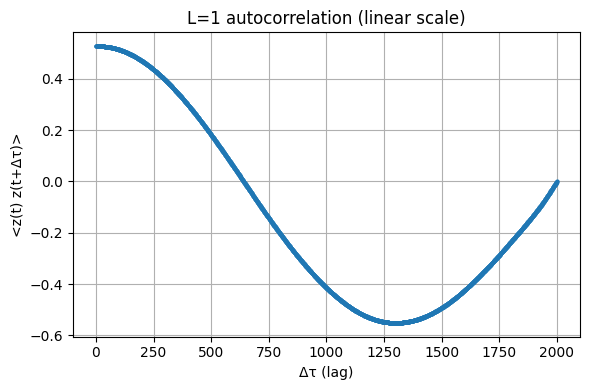

In [ ]:
# Simple linear plot (required)
plt.figure(figsize=(6, 4))
plt.plot(lags, C, marker='.', markersize=4)
plt.xlabel('Δτ (lag)')
plt.ylabel('<z(t) z(t+Δτ)>')
plt.title('L=1 autocorrelation (linear scale)')
plt.grid(True)
plt.tight_layout()
plt.show()

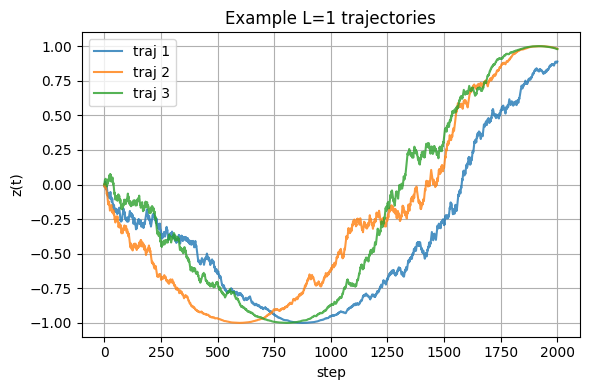

In [ ]:
# Trajectory preview next to the autocorrelation
plt.figure(figsize=(6, 4))
n_preview = min(3, z_trajs.shape[0])
for idx in range(n_preview):
    plt.plot(z_trajs[idx], alpha=0.8, label=f'traj {idx + 1}')
plt.xlabel('step')
plt.ylabel('z(t)')
plt.title('Example L=1 trajectories')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

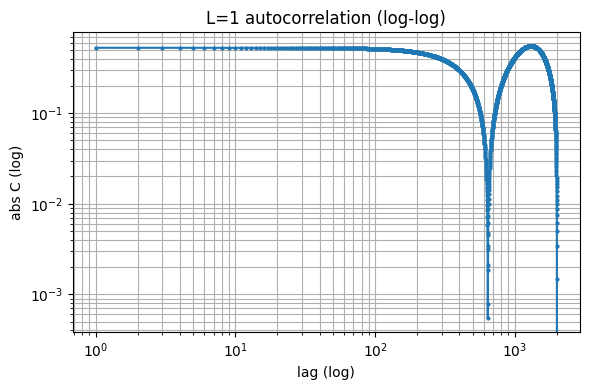

In [ ]:
# Optional log-log view for power-law inspection
plt.figure(figsize=(6, 4))
plt.loglog(lags[1:], np.abs(C[1:]), marker='.', markersize=4)
plt.xlabel('lag (log)')
plt.ylabel('abs C (log)')
plt.title('L=1 autocorrelation (log-log)')
plt.grid(True, which='both')
plt.tight_layout()
plt.show()

## Optional fitting
Below you can add fits for power-law and exponential models. This cell is optional and can be skipped during quick runs.

Power-law fit: A=8.2521e-01, alpha=0.1218
Exp fit: B=5.7444e-01, tau=786.7109


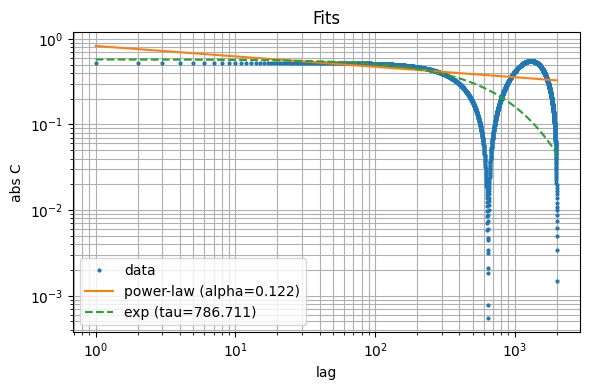

In [ ]:
from scipy.optimize import curve_fit

def power_law(k, A, alpha):
    return A * (k ** (-alpha))

def exp_decay(k, B, tau):
    return B * np.exp(-k / tau)

k = np.arange(1, C.size)
y = np.abs(C[1:])
k_min = 5
k_max = max(20, int(0.2 * k.size))
try:
    popt_p, _ = curve_fit(power_law, k[k_min:k_max], y[k_min:k_max], p0=[y[k_min], 1.0])
    popt_e, _ = curve_fit(exp_decay, k[k_min:k_max], y[k_min:k_max], p0=[y[k_min], 10.0])
    print('Power-law fit: A=%.4e, alpha=%.4f' % (popt_p[0], popt_p[1]))
    print('Exp fit: B=%.4e, tau=%.4f' % (popt_e[0], popt_e[1]))
    plt.figure(figsize=(6, 4))
    plt.loglog(k, y, '.', markersize=4, label='data')
    plt.loglog(k, power_law(k, *popt_p), '-', label=f'power-law (alpha={popt_p[1]:.3f})')
    plt.loglog(k, exp_decay(k, *popt_e), '--', label=f'exp (tau={popt_e[1]:.3f})')
    plt.legend()
    plt.xlabel('lag')
    plt.ylabel('abs C')
    plt.title('Fits')
    plt.grid(True, which='both')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Fitting failed:', e)